# **Modelado con validación segura (Etapa 2)**

Respecto a lo evidenciado en etapas anteriores, ahora para el preprocesamiento vamos a tratar los valores faltantes, y toda las filas de `Cholesterol` identificadas como 0. Además, de utilizar `OneHotEnconder` para las variables categóricas, escalar las variables numéricas con `Scaler`. Para los datos faltantes, se utilizará `SimpleImputer` reeemplazando por la mediana. También nos veremos infleunciados por el siguiente flujo:

1. División de datos **antes** de cualquier transformación
2. `Pipeline` con `GridSearchCV` para evitar data leakage
3. Evaluación detallada: **Matriz de confusión**, **Curva ROC** y **AUC**
4. Selección y exportación del mejor modelo

Gracias a la etapa anterior, vimos lo importante que es dividir antes de escalar o hacer alguna clase de transformación a los datos. Es por eso, que primero se dividira antes de iniciar con el proceso de modelado, hasta encontrar el que tenga el mejor score. Posteriormente, se evalará su rendimiento mediante la matriz de confusión, la curva ROC y el AUC. y por útimo, se importara en un archivo `joblib`.

## **1. Importación de librerías**

A continuación, cargaremos todas las librerías a utilizar junto con la base datos.

In [14]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.impute import SimpleImputer
from sklearn import metrics
import seaborn as sns
import warnings
from sklearn.compose import ColumnTransformer
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    confusion_matrix, RocCurveDisplay, roc_curve
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import joblib, os




# cargamos los datos
df = pd.read_csv("data/heart.csv")
df["FastingBS"] = df["FastingBS"].astype("object") #convertimos a 'FastingBS' catalogada como numérica a categórica.

## **2. División antes del preprocesamiento**

In [15]:
# separamos en variables predictoras y variable respuesta
X = df.drop(columns="HeartDisease")
y = df["HeartDisease"]

# dividimos antes de imputar para evitar data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Dimensión del conjunto de entrenamiento:", len(X_train))
print("Dimensión del conjunto de prueba:", len(X_test))

Dimensión del conjunto de entrenamiento: 734
Dimensión del conjunto de prueba: 184


Según lo visto en el notebook anterior, vimos la importancia de dividir antes de escalar o hacer algún tipo de transformaciones a los datos. 

## **3. Transformaciones en los datos**

Después de dividir, procedemos a aplicar `MinMaxScaler` para las numéricas y `OneHotEncoder` para las categóricas.


In [16]:
# copias para no modificar las originales
X_train_copia = X_train.copy()
X_test_copia = X_test.copy()

# -------------- ColmunTransfomer--------------

# separamos en variables categóricas y numéricas
num_columnas = X_train_copia.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_columnas = X_train_copia.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", len(num_columnas))
print("Categóricas:", len(cat_columnas))
print("Columnas numéricas:", num_columnas)
print("Columnas categóricas:", cat_columnas)

# -------------- Preprocesamiento --------------
# vamos a utilizar OneHotEnconder para las categóricas y MinMaxScaler para estandarizar las numéricas.
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first", handle_unknown='ignore'), cat_columnas),
    ("num", Pipeline([
        ("imputer", SimpleImputer(missing_values=0, strategy="median")),
        ("scaler", MinMaxScaler())
    ]), num_columnas)
])


Numéricas: 5
Categóricas: 6
Columnas numéricas: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Columnas categóricas: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


## **4. Entrenamiento del modelo**

A continuación se hara el modelado, para eso se empleara la función `GridSearch` y todo se hará mediante la ejecución de Pipelines. Se evaluarán los modelos de Regresión logísitca, SVC, Random Forest, KNN y Gradient Boosting. En cada uno se evaluara el AUC, y el mejor AUC obtenido por medio de validación cruzada.

Primero, mostramos las funciones reutilizables que se usaran para entrenar el modelo:

In [17]:
# -------------- FUNCIONES REUTILIZABLES --------------
# creamos función para facilitar el entrenamiento de cada modelo
def train_pipeline(transformacion, X_train, y_train, model, param_grid):
    
    if transformacion is None:   
        pipe = Pipeline([("clf", model)])
    else:
        pipe = Pipeline([
            ("preprocessor", transformacion),
            ("clf", model)
        ])
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc")
    grid.fit(X_train, y_train)
    return grid


def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    auc_VC = modelo.best_score_
    mejores_parametros = modelo.best_params_
    
    return auc, accuracy, auc_VC, mejores_parametros


def entrenamiento_modelo(transformacion, modelos, X_train, y_train, X_test, y_test):
    resultados = []
    grids_entrenados = {}
    
    for name, (model, params) in modelos.items():
        grid = train_pipeline(transformacion, X_train, y_train, model, params)
        grids_entrenados[name] = grid
        
        auc, acc, auc_VC, mejores_parametros = evaluar_modelo(grid, X_test, y_test)
        
        resultados.append([name, auc, acc, auc_VC, mejores_parametros])
    
    return pd.DataFrame(resultados, columns=["Modelo", "AUC", "Accuracy", "AUC VC", "Mejores parametros"]), grids_entrenados      


# definimos los modelos a utilizar con su param grid 
modelos = {
    "SVC": (
        SVC(probability=True, random_state=42),
        {"clf__C": [0.1, 1, 10], "clf__gamma": [0.01, 0.1]}
    ),
    "LogisticRegression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {"clf__C": [0.1, 1, 10]}
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {"clf__n_estimators": [100, 200], "clf__max_depth":[None, 5, 10]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [3, 5, 7]}
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {"clf__n_estimators": [100, 200], "clf__learning_rate":[0.01, 0.1]}
    )
}

In [19]:
grid_search, grids = entrenamiento_modelo(preprocessor, modelos, X_train_copia, y_train, X_test_copia, y_test)
grid_search = grid_search.sort_values("AUC", ascending=False).reset_index(drop=True)
grid_search.index += 1
grid_search[["Modelo", "AUC", "Accuracy", "AUC VC"]]

,Modelo,AUC,Accuracy,AUC VC
1,RandomForest,0.941655,0.891304,0.925795
2,SVC,0.933525,0.858696,0.917403
3,LogisticRegression,0.931253,0.885870,0.919121
4,KNN,0.923063,0.880435,0.894158
5,GradientBoosting,0.920732,0.858696,0.922497


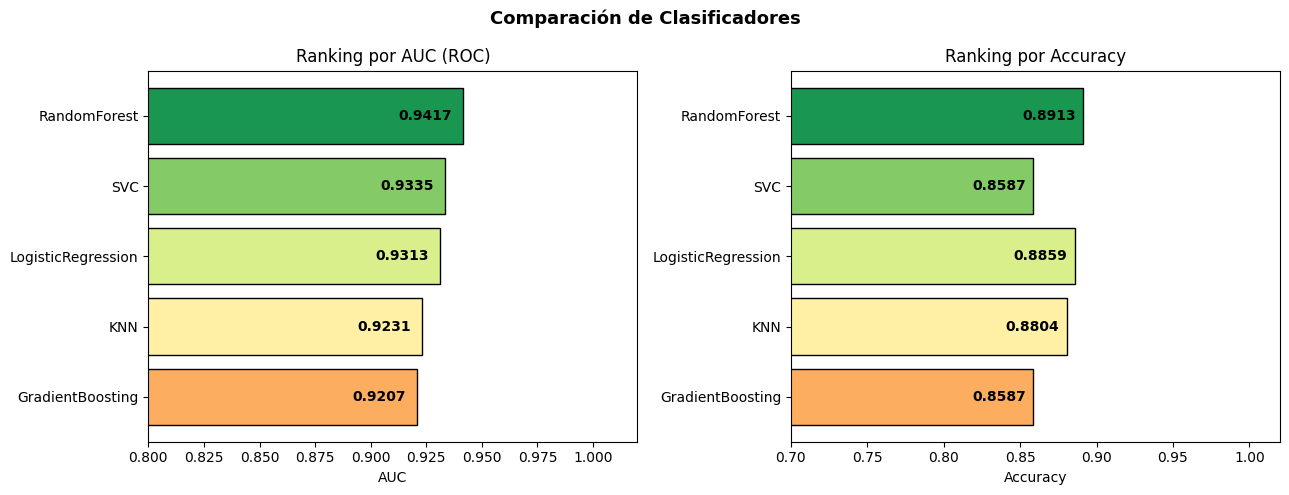

In [8]:
# Visualización del ranking
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

modelos  = grid_search['Modelo']
aucs     = grid_search['AUC']
accs     = grid_search['Accuracy']
colores  = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(modelos)))

# Gráfico AUC
bars1 = axes[0].barh(modelos[::-1], aucs[::-1], color=colores, edgecolor='black')
for bar, val in zip(bars1, aucs[::-1]):
    axes[0].text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', ha='right', va='center', fontsize=10, fontweight='bold', color='black')
axes[0].set_xlabel('AUC')
axes[0].set_title('Ranking por AUC (ROC)')
axes[0].set_xlim(0.8, 1.02)

# Gráfico Accuracy
bars2 = axes[1].barh(modelos[::-1], accs[::-1], color=colores, edgecolor='black')
for bar, val in zip(bars2, accs[::-1]):
    axes[1].text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', ha='right', va='center', fontsize=10, fontweight='bold', color='black')
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Ranking por Accuracy')
axes[1].set_xlim(0.7, 1.02)

plt.suptitle('Comparación de Clasificadores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La tabla muestra los resultados de cada modelo sobre el conjunto de prueba, usando métricas como AUC, Accuracy y el promedio del AUC obtenido por validación cruzada (AUC VC).
En términos generales, todos los modelos se comportaron muy bien: ninguno bajó de 0.90 en ninguna de las métricas. Algo que también llama la atención es que las diferencias entre el AUC en test y el de validación cruzada son bastante pequeñas (ninguna supera 0.028), lo que indica que los modelos no se están simplemente "memorizando" los datos, sino que logran generalizar bien a ejemplos nuevos. A primera vista, RandomForest destaca ligeramente con un AUC cercano a 0.94. Dicho esto, las diferencias entre modelos son tan pequeñas que no conviene apresurarse a declarar un ganador claro. Además, de que los resultados pueden variar dependiendo de la cantidad de parámetros que se hayan definido previamente.
En definitiva, todos los modelos evaluados rinden de forma muy parecida. Por eso, a la hora de elegir uno, tiene sentido mirar más allá de los números y considerar aspectos como qué tan fácil es interpretar sus decisiones, qué tan complejo es el modelo o cuánto tiempo y recursos consume.

Sabemos que se obtuvo un `ROC-AUC = 0.94`, lo que indica que existe un 94% de probabilidad de que el modelo asigne un mayor score de probabilidad a un paciente que realmente padece enfermedad cardíaca que a uno que no la padece. En otras palabras, el modelo logra discriminar de manera eficiente entre pacientes con y sin enfermedad cardíaca en términos de sus probabilidades predichas.

Por otro lado, el mejor accuracy fue de 0.89, obtenido también por el modelo de Random Forest. En otros escenarios, esta métrica podría no ser la más adecuada debido a su sensibilidad al desbalance de clases; sin embargo, en este caso, como el dataset no presenta un desbalance significativo, su interpretación sigue siendo válida. Esto indica que el modelo clasifica correctamente el 89% de los casos, mientras que el 11% restante corresponde a predicciones incorrectas. En general, se observa un buen desempeño en ambas métricas. No obstante, para la selección del mejor modelo se priorizará el AUC, ya que proporciona una evaluación más robusta de la capacidad de discriminación del modelo.

## **5. Selección del mejor modelo**

De acuerdo a los resultados anteriores, procedemos a escoger el mejor modelo mediante AUC y posteriomente a evaluar su matriz de confusión y su curva ROC.

In [10]:
mejor_nombre = grid_search.iloc[0]["Modelo"]
mejor_grid = grids[mejor_nombre]
print(f"Mejor modelo: {mejor_nombre}")
print(f"Mejores parámetros: {mejor_grid.best_params_}")

Mejor modelo: RandomForest
Mejores parámetros: {'clf__max_depth': None, 'clf__n_estimators': 200}


El mejor modelo obtenido fue Random Forest, sin profundida máxima y un número de árboles de 200. Una vez identificado el modelo con mejor desempeño, se procede a evaluar su rendimiento mediante la matriz de confusión y la curva ROC, con el fin de analizar en detalle su capacidad de clasificación y discriminación.

### **5.1 Matriz de confusión**

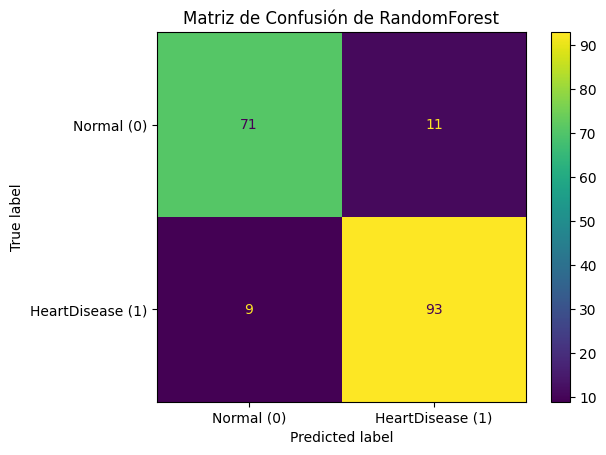

In [20]:
y_pred_mejor = mejor_grid.predict(X_test)

confusion_matrix = metrics.confusion_matrix(y_test, y_pred_mejor)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ["Normal (0)", "HeartDisease (1)"])

cm_display.plot()
plt.title('Matriz de Confusión de '+ mejor_nombre)
plt.show()

En la matriz de confusión se observa que TP = 71, FP = 11, FN = 9 y TN = 93. Es decir, 71 pacientes que padecen enfermedad cardíaca fueron correctamente identificados por el modelo; 11 pacientes sin enfermedad fueron clasificados incorrectamente como positivos; 9 pacientes con enfermedad cardíaca fueron clasificados erróneamente como sanos, lo cual resulta especialmente crítico en el contexto médico; y 93 pacientes sanos fueron correctamente clasificados. En general, el modelo presenta un buen desempeño; sin embargo, aún se presentan falsos negativos, lo cual es preocupante, ya que implica no detectar pacientes que realmente tienen la enfermedad. En este contexto, esto podría traducirse en consecuencias graves para los pacientes. Por lo tanto, sería recomendable enfocar los esfuerzos en mejorar el recall del modelo, con el fin de reducir este tipo de errores.

### **5.2 Curva ROC**

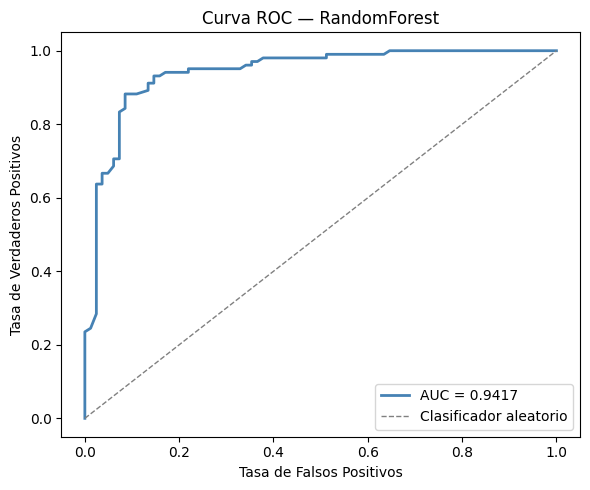

In [12]:
y_proba_mejor = mejor_grid.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_mejor)
auc_mejor = roc_auc_score(y_test, y_proba_mejor)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_mejor:.4f}")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title(f"Curva ROC — {mejor_nombre}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

En la curva ROC, el eje horizontal representa la tasa de falsos positivos (FPR), mientras que el eje vertical representa la tasa de verdaderos positivos (TPR), también conocida como recall. Valores más pequeños en el eje FPR indican menos falsos positivos (FP) y más verdaderos negativos (TN), mientras que valores más altos en el eje TPR indican más verdaderos positivos (TP) y menos falsos negativos (FN). En este caso, la curva ROC se encuentra cercana a la esquina superior izquierda, lo que indica un excelente desempeño del modelo. Además, el valor de ROC-AUC de aproximadamente 0.94 confirma que el modelo tiene una alta capacidad de discriminación, logrando separar de manera efectiva a los pacientes con y sin enfermedad cardíaca en función de las probabilidades predichas.

## **6. Exportación del mejor modelo**

A continuación, procedemos a exportar el mejor modelo obtuvio en los pasos anteriores, se exportará con el hecho de hacer más fácil su manejo

In [ ]:
# Exportar el mejor modelo
mejor_modelo = mejor_nombre
joblib.dump(grids[mejor_modelo].best_estimator_, "model.joblib")
print(f"Modelo '{mejor_modelo}' exportado exitosamente.")

Modelo 'RandomForest' exportado exitosamente.
